In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import Data
* Import and define the data as df
* Define the vector of lost values

In [2]:
lost = ["NaN","None","NULL","NA","N/A","?","null",""]
df = pd.read_csv("C:\\Users\\jhons\\OneDrive\\Documentos\\GitHub proyects\\Datasets\\Gold Price\\finalgolddata.csv", na_values=lost)

## First 10 rows

In [3]:
df.head(10)

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
5,07-09-00,274.000000,274.000000,274.000000,274.000000,125
6,08-09-00,273.299988,273.299988,273.299988,273.299988,0
7,11-09-00,273.100006,273.100006,273.100006,273.100006,0
8,12-09-00,272.899994,272.899994,272.899994,272.899994,0
9,13-09-00,272.799988,272.799988,272.799988,272.799988,0


## Last 10 rows 

In [4]:
df.tail(10)

,Date,Open,High,Low,Close,Volume
6389,18-02-26,4872.200195,4987.000000,4869.500000,4986.500000,544
6390,19-02-26,5014.700195,5014.700195,4975.899902,4975.899902,37
6391,20-02-26,5039.500000,5072.700195,5039.500000,5059.299805,134
6392,23-02-26,5120.299805,5211.600098,5120.299805,5204.700195,779
6393,24-02-26,5158.799805,5159.000000,5112.700195,5155.799805,88
6394,25-02-26,5166.000000,5206.399902,5166.000000,5206.399902,1772
6395,26-02-26,5177.200195,5199.200195,5143.899902,5176.500000,1520
6396,27-02-26,5186.700195,5280.000000,5176.700195,5230.500000,354
6397,02-03-26,5346.600098,5405.000000,5266.299805,5294.399902,354
6398,03-03-26,5335.700195,5394.200195,5334.899902,5377.299805,21189


## Matriz size and shape

In [5]:
print(df.size)
print(df.shape)

38394
(6399, 6)


## Variable types and info


In [6]:
print(df.dtypes)
print(df.info)

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object
<bound method DataFrame.info of           Date         Open         High          Low        Close  Volume
0     30-08-00   273.899994   273.899994   273.899994   273.899994       0
1     31-08-00   274.799988   278.299988   274.799988   278.299988       0
2     01-09-00   277.000000   277.000000   277.000000   277.000000       0
3     05-09-00   275.799988   275.799988   275.799988   275.799988       2
4     06-09-00   274.200012   274.200012   274.200012   274.200012       0
...        ...          ...          ...          ...          ...     ...
6394  25-02-26  5166.000000  5206.399902  5166.000000  5206.399902    1772
6395  26-02-26  5177.200195  5199.200195  5143.899902  5176.500000    1520
6396  27-02-26  5186.700195  5280.000000  5176.700195  5230.500000     354
6397  02-03-26  5346.600098  5405.000000  5266.299805  5294.399902     354
6398  03-03-26  5335.

## Sumary of the number variabless

In [7]:
df.describe()

,Open,High,Low,Close,Volume
count,6399.000000,6399.000000,6399.000000,6399.000000,6399.000000
mean,1274.892437,1281.728724,1267.908032,1274.961009,4282.543522
std,782.868133,788.800733,777.090788,783.122438,24051.637361
min,255.000000,256.100006,255.000000,255.100006,0.000000
25%,651.000000,653.649994,649.149994,651.699982,23.000000
50%,1251.599976,1256.199951,1244.800049,1251.099976,117.000000
75%,1694.700012,1706.099976,1683.250000,1695.649964,450.500000
max,5415.700195,5586.200195,5334.899902,5377.299805,386334.000000


## NaN and Duplicated values

In [8]:
print("NaN:\n",df.isna().sum())
print("Duplicates:\n",df.duplicated().sum())

NaN:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Duplicates:
 0


# Graphic visualization with Matplotlip

# Boxplots

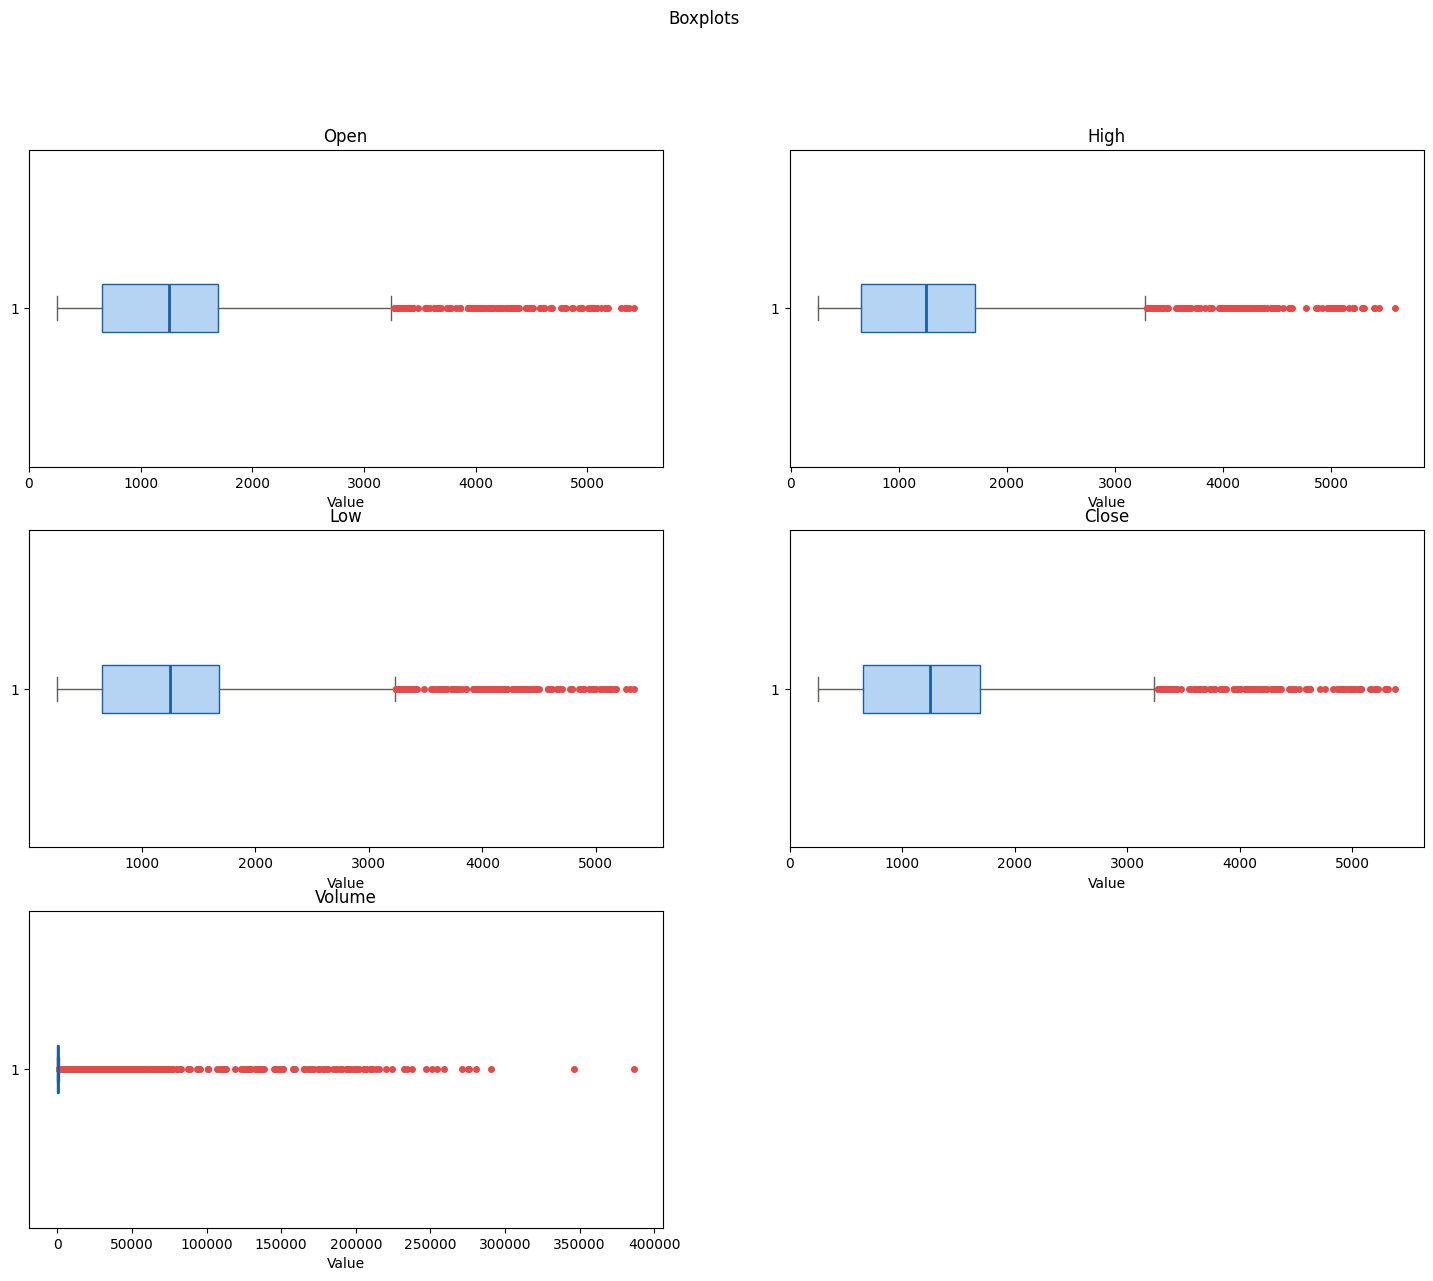

In [9]:
vn = df.select_dtypes("number").columns.to_list()
n = len(vn)

fig,axes = plt.subplots(3, 2, figsize=(18,14))
axes = axes.flatten()

for i,col in enumerate(vn):
    axes[i].boxplot(df[col].dropna(),
        vert=False,           
        patch_artist=True,     
        boxprops=dict(facecolor='#B5D4F4', color='#185FA5'), # box color
        medianprops=dict(color='#185FA5', linewidth=2),        # median line
        whiskerprops=dict(color='#5F5E5A'),                    # plots
        capprops=dict(color='#5F5E5A'),                        # plots limits
        flierprops=dict(marker='o', markerfacecolor='#E24B4A', # outliers
                        markeredgecolor='#E24B4A', markersize=4)
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots")
plt.show()

## Hist

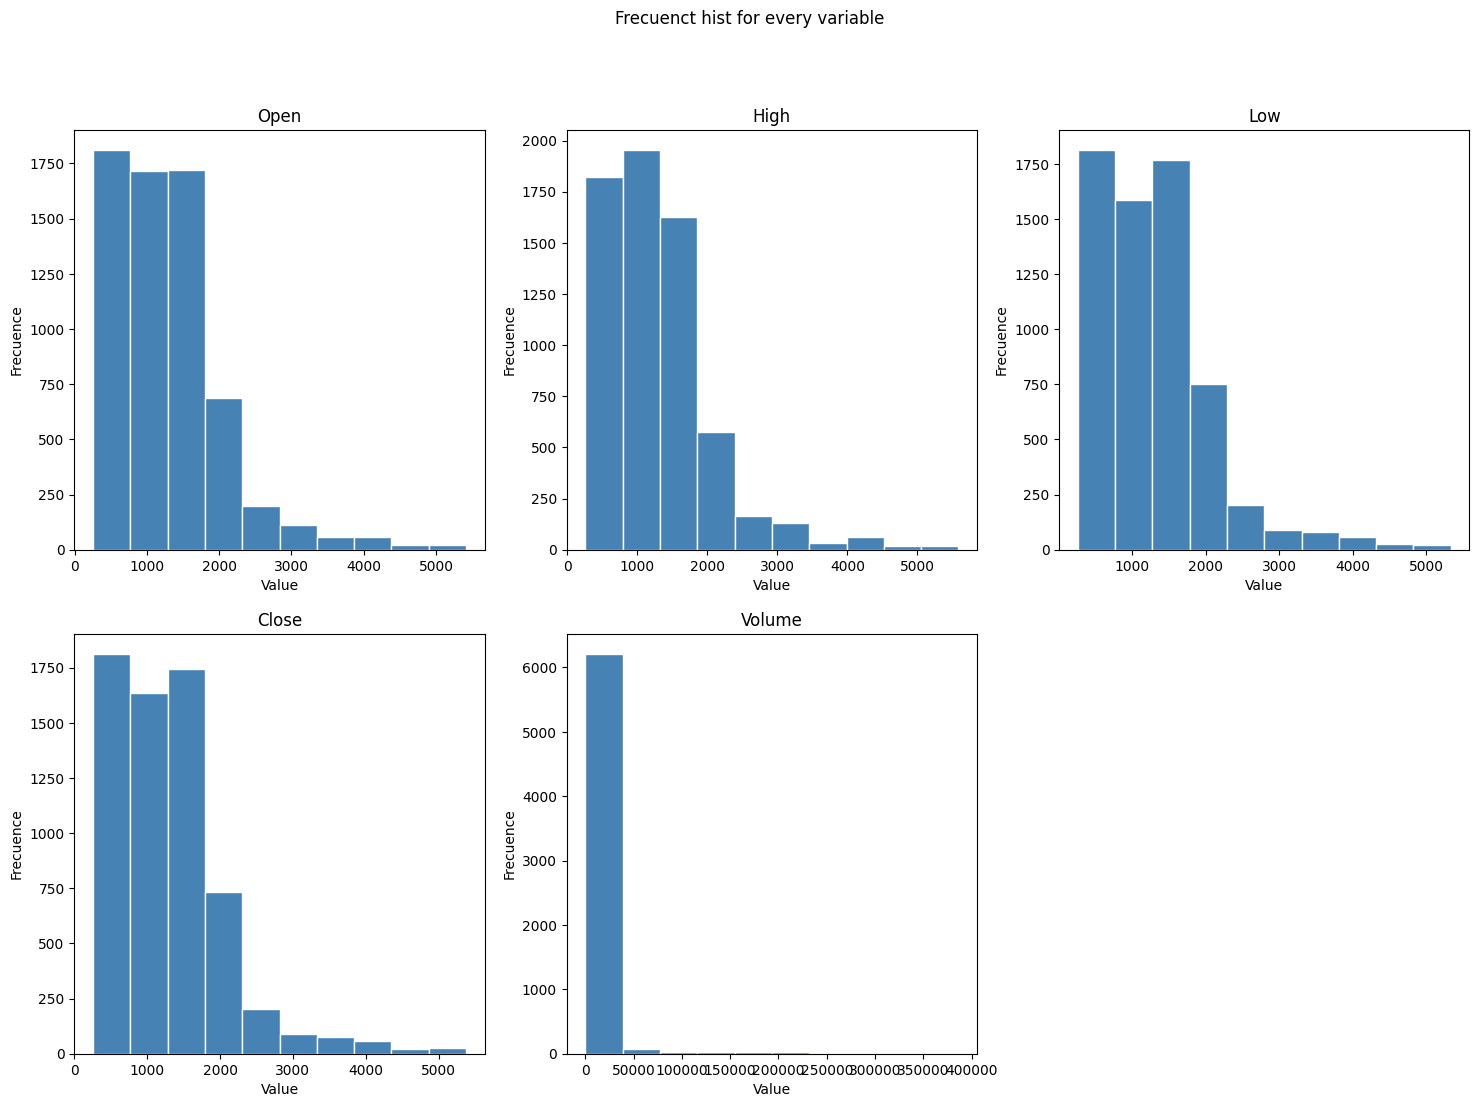

In [10]:
# Select the data
nv = df.select_dtypes(include="number").columns.to_list()
n = len(nv)

#Create the plot set with his respectives subplots sets
fig, axes = plt.subplots(2,3, figsize=(18,12))
axes = axes.flatten() # Transform a the matriz to a vector

# Iter the respective column to the subplot
for i, col in enumerate(nv):
    axes[i].hist(df[col].dropna(), color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frecuence")

# Not show the ecxedent data.
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Show the graphics
plt.suptitle("Frecuenct hist for every variable")
plt.show()

## Density funtion

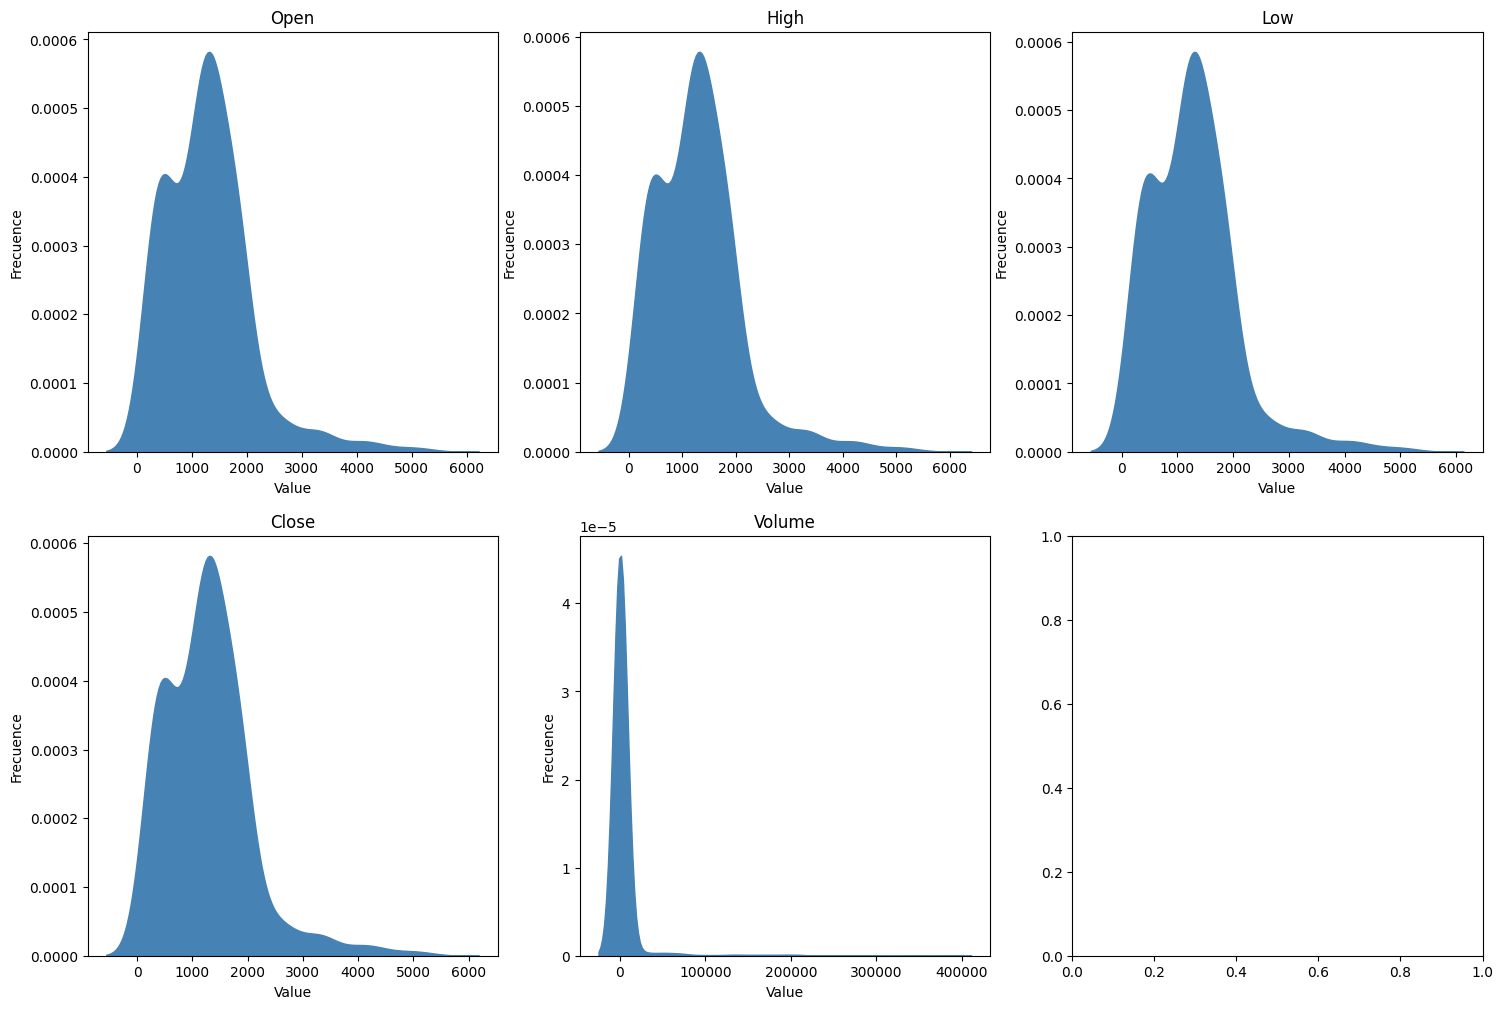

In [11]:
vn = df.select_dtypes("number").columns.to_list()
n = len(nv)

fig,axes = plt.subplots(2,3,figsize=(18,12))
axes = axes.flatten()

for i,col in enumerate(nv):
   
    sns.kdeplot(df[col],
                fill=True,
                ax=axes[i],
                color="steelblue",
                alpha=1,
                bw_adjust=2.0)
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frecuence")

# Scarplots

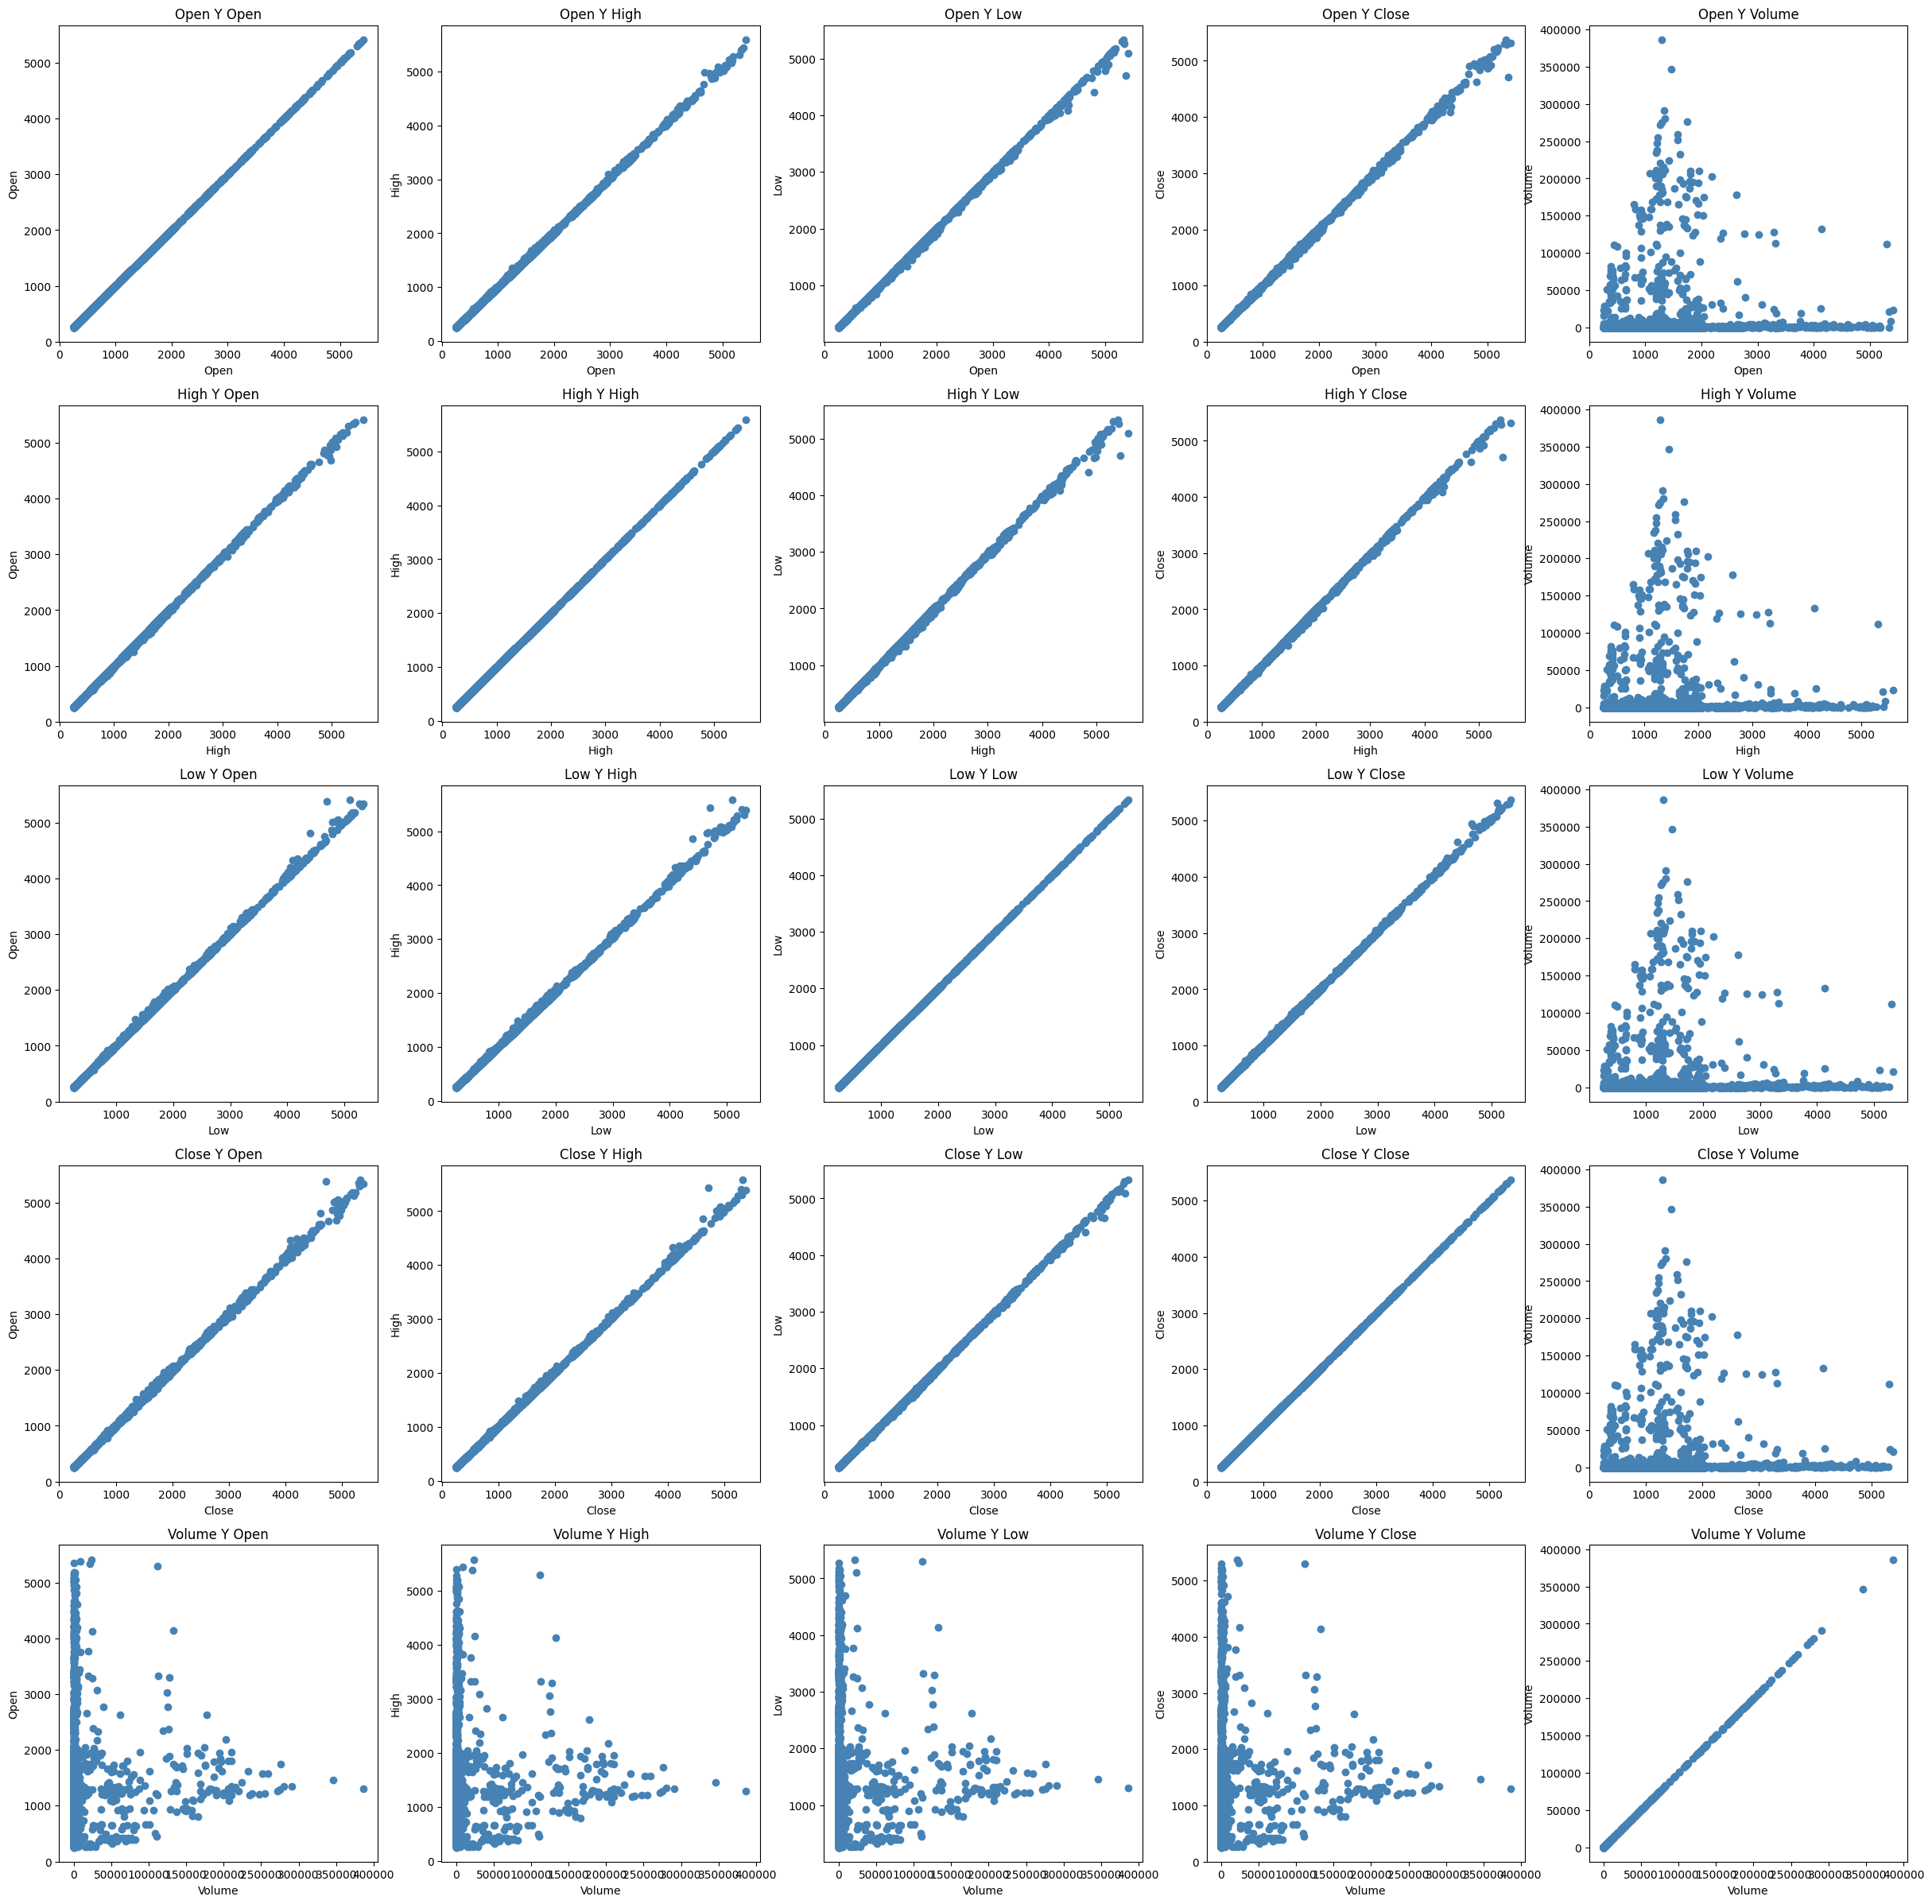

In [12]:
vn = df.select_dtypes("number").columns.to_list()
n = len(nv)

fig, axes = plt.subplots(5,5,figsize=(30,30))

for i,col1 in enumerate(nv):
    for j,col2 in enumerate(nv):
        axes[i][j].scatter(df[col1],
                        df[col2],
                        color="steelblue")

        axes[i][j].set_title("{} Y {}".format(df.select_dtypes("number").columns[i],df.select_dtypes("number").columns[j]))
        axes[i][j].set_xlabel(df.select_dtypes("number").columns[i])
        axes[i][j].set_ylabel(df.select_dtypes("number").columns[j])

# Matrix corr

In [13]:
mc = df.select_dtypes("number").corr(method='pearson')
print(mc)

            Open      High       Low     Close    Volume
Open    1.000000  0.999908  0.999806  0.999755  0.033146
High    0.999908  1.000000  0.999745  0.999833  0.032307
Low     0.999806  0.999745  1.000000  0.999910  0.033785
Close   0.999755  0.999833  0.999910  1.000000  0.032927
Volume  0.033146  0.032307  0.033785  0.032927  1.000000


# Headmap

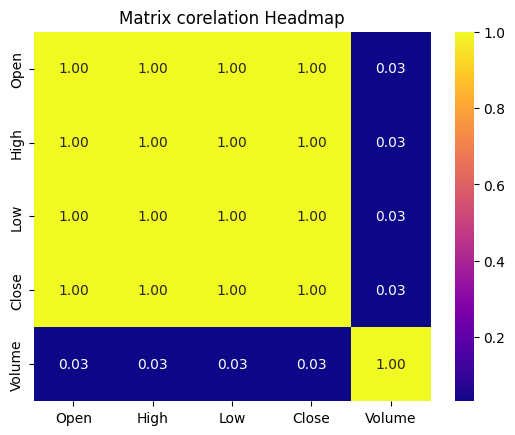

In [14]:
vn = df.select_dtypes("number").columns.to_list()
n = len(vn)

sns.heatmap(mc,
            annot=True,
            cmap="plasma",
            fmt=".2f")

plt.title("Matrix corelation Headmap")
plt.show()

# Series Time by Open

In [15]:
print(df["Date"].head())
print(df["Date"].tail())

0    30-08-00
1    31-08-00
2    01-09-00
3    05-09-00
4    06-09-00
Name: Date, dtype: object
6394    25-02-26
6395    26-02-26
6396    27-02-26
6397    02-03-26
6398    03-03-26
Name: Date, dtype: object


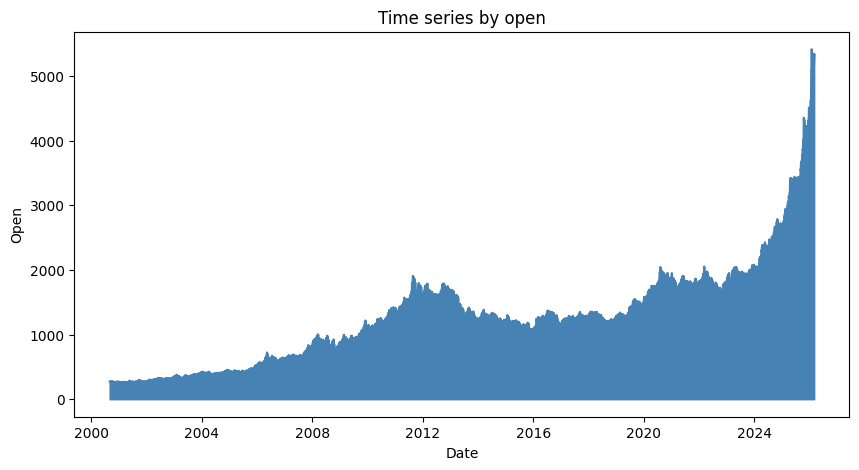

In [16]:
date = pd.to_datetime(df["Date"], format='%d-%m-%y')
value = df["Open"]

df.set_index(date, inplace=True)

plt.figure(figsize=(10,5))

plt.plot(date, value, color="steelblue")
plt.fill_between(date, value, color="steelblue", alpha=1)

plt.title("Time series by open")
plt.xlabel("Date")
plt.ylabel("Open")

plt.show()

# Series Time by Close

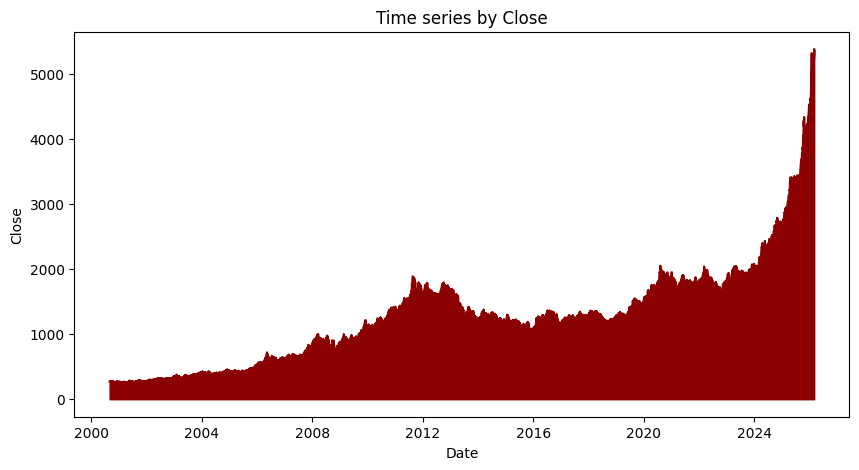

In [17]:
date = pd.to_datetime(df["Date"], format='%d-%m-%y')
value = df["Close"]

df.set_index(date, inplace=True)

plt.figure(figsize=(10,5))

plt.plot(date, value, color="darkred")
plt.fill_between(date, value, color="darkred", alpha=1)

plt.title("Time series by Close")
plt.xlabel("Date")
plt.ylabel("Close")

plt.show()

# Grow by day in the Open

In [20]:
df["GrowByOpen"] = df["Open"].dropna().pct_change()
df["GrowByOpen"].head()


Date
2000-08-30         NaN
2000-08-31    0.003286
2000-09-01    0.008006
2000-09-05   -0.004332
2000-09-06   -0.005801
Name: GrowByOpen, dtype: float64

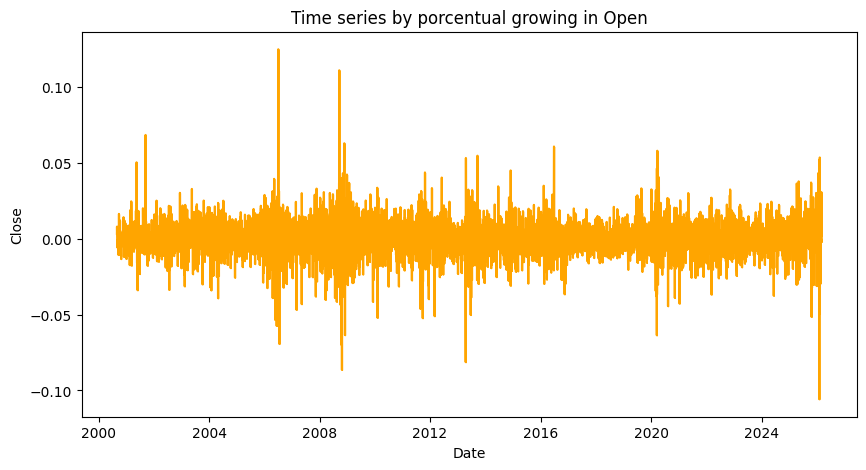

In [27]:
date = pd.to_datetime(df["Date"], format='%d-%m-%y')
value = df["GrowByOpen"]

df.set_index(date, inplace=True)

plt.figure(figsize=(10,5))

plt.plot(date, value, color="orange")
plt.fill_between(date, value, color="orange", alpha=1)

plt.title("Time series by porcentual growing in Open")
plt.xlabel("Date")
plt.ylabel("Close")

plt.show()

In [26]:
print(f"Max growing: {df["GrowByOpen"].max():.2%}")
print(f"Max degrowth: {df["GrowByOpen"].min():.2%}")

Max growing: 12.50%
Max degrowth: -10.58%


# # Grow by day in the Close

In [28]:
df["GrowByClose"] = df["Close"].dropna().pct_change()
df["GrowByClose"].head()

Date
2000-08-30         NaN
2000-08-31    0.016064
2000-09-01   -0.004671
2000-09-05   -0.004332
2000-09-06   -0.005801
Name: GrowByClose, dtype: float64

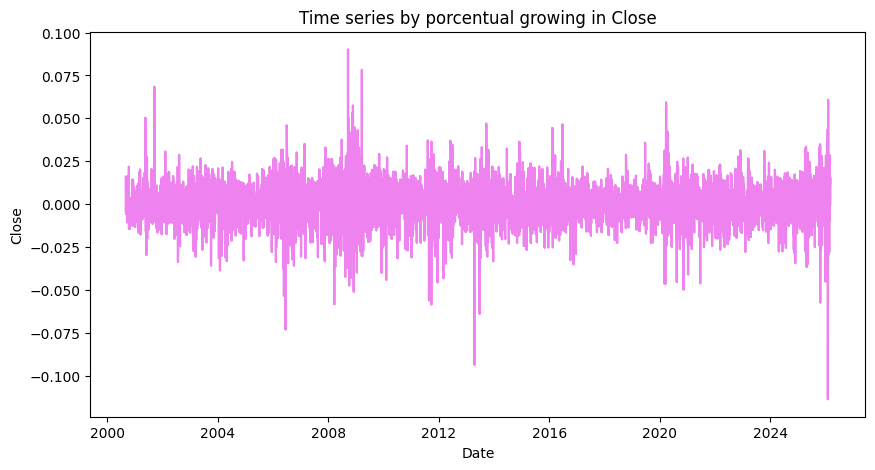

In [32]:
date = pd.to_datetime(df["Date"], format='%d-%m-%y')
value = df["GrowByClose"]

df.set_index(date, inplace=True)

plt.figure(figsize=(10,5))

plt.plot(date, value, color="violet")
plt.fill_between(date, value, color="violet", alpha=1)

plt.title("Time series by porcentual growing in Close")
plt.xlabel("Date")
plt.ylabel("Close")

plt.show()

In [33]:
print(f"Max growing: {df["GrowByClose"].max():.2%}")
print(f"Max degrowth: {df["GrowByClose"].min():.2%}")

Max growing: 9.03%
Max degrowth: -11.37%
